# <a id='toc1_'></a>[Custom models with PyTorch](#toc0_)

This tutorial can be found [here](https://ts.gluon.ai/stable/tutorials/advanced_topics/howto_pytorch_lightning.html)

This notebook illustrates how one can
- implement a time series model in GluonTS using PyTorch
- train it with PyTorch Lightning
- and use it together with the rest of the GluonTS ecosystem for
  - data loading
  - feature processing
  - and model evaluation.

**Table of contents**<a id='toc0_'></a>    
- [Custom models with PyTorch](#toc1_)    
  - [Probabilistic feed-forward network using PyTorch](#toc1_1_)    
  - [Defining the training data loader](#toc1_2_)    
  - [Train the model](#toc1_3_)    
  - [Create predictor out of the trained model, and test it](#toc1_4_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

Import packages

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates

from typing import List, Optional, Callable, Iterable
from itertools import islice
from gluonts.dataset.repository import get_dataset

c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\gluonts\json.py:102: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(


For this example we will use the "electricity" dataset, which can be loaded as follows.

In [2]:
# download built-in dataset from GluonTS
# https://ts.gluon.ai/stable/api/gluonts/gluonts.dataset.common.html?highlight=gluonts%20dataset%20common%20traindatasets#gluonts.dataset.common.TrainDatasets
dataset = get_dataset("electricity")

In [33]:
print(type(dataset))  # gluonts.dataset.common.TrainDatasets

<class 'gluonts.dataset.common.TrainDatasets'>


MetaData(freq='1h', target=None, feat_static_cat=[CategoricalFeatureInfo(name='feat_static_cat_0', cardinality='321')], feat_static_real=[], feat_dynamic_real=[], feat_dynamic_cat=[], prediction_length=24)

In [34]:
print(dataset.metadata)  # contains metadata about the dataset

freq='1h' target=None feat_static_cat=[CategoricalFeatureInfo(name='feat_static_cat_0', cardinality='321')] feat_static_real=[] feat_dynamic_real=[] feat_dynamic_cat=[] prediction_length=24


In [35]:
dataset.train  # training set

Map(fn=<gluonts.dataset.common.ProcessDataEntry object at 0x0000014DF783B770>, iterable=JsonLinesFile(path=WindowsPath('C:/Users/Mike/.gluonts/datasets/electricity/train/data.json.gz'), start=0, n=None, line_starts=[np.int32(0), np.int32(120815), np.int32(261525), np.int32(374370), np.int32(521826), np.int32(668740), np.int32(819180), np.int32(944958), np.int32(1103444), np.int32(1250251), np.int32(1396802), np.int32(1543225), np.int32(1690607), np.int32(1836852), np.int32(1980026), np.int32(2127368), np.int32(2284926), np.int32(2411269), np.int32(2557789), np.int32(2706551), np.int32(2843220), np.int32(2969577), np.int32(3123603), np.int32(3255061), np.int32(3386009), np.int32(3533393), np.int32(3680345), np.int32(3827729), np.int32(3954394), np.int32(4101796), np.int32(4238787), np.int32(4386204), np.int32(4533588), np.int32(4680199), np.int32(4826792), np.int32(4995229), np.int32(5135202), np.int32(5282119), np.int32(5429733), np.int32(5568874), np.int32(5696184), np.int32(5864609),

In [36]:
dataset.test  # test set

Map(fn=<gluonts.dataset.common.ProcessDataEntry object at 0x0000014DF788A490>, iterable=JsonLinesFile(path=WindowsPath('C:/Users/Mike/.gluonts/datasets/electricity/test/data.json.gz'), start=0, n=None, line_starts=[np.int32(0), np.int32(120947), np.int32(261816), np.int32(374782), np.int32(522406), np.int32(669488), np.int32(820096), np.int32(946016), np.int32(1104682), np.int32(1251656), np.int32(1398373), np.int32(1544963), np.int32(1692513), np.int32(1838925), np.int32(1982254), np.int32(2129764), np.int32(2287497), np.int32(2413984), np.int32(2560671), np.int32(2709601), np.int32(2846425), np.int32(2972926), np.int32(3127124), np.int32(3258730), np.int32(3389825), np.int32(3537377), np.int32(3684497), np.int32(3832049), np.int32(3958858), np.int32(4106428), np.int32(4243583), np.int32(4391168), np.int32(4538720), np.int32(4685486), np.int32(4832247), np.int32(5000876), np.int32(5141002), np.int32(5288087), np.int32(5435869), np.int32(5575169), np.int32(5702623), np.int32(5871240), 

This is what the first time series from the training portion of the dataset look like:

0: dict_keys(['target', 'start', 'feat_static_cat', 'item_id'])
1: dict_keys(['target', 'start', 'feat_static_cat', 'item_id'])
2: dict_keys(['target', 'start', 'feat_static_cat', 'item_id'])
3: dict_keys(['target', 'start', 'feat_static_cat', 'item_id'])
4: dict_keys(['target', 'start', 'feat_static_cat', 'item_id'])
5: dict_keys(['target', 'start', 'feat_static_cat', 'item_id'])
6: dict_keys(['target', 'start', 'feat_static_cat', 'item_id'])
7: dict_keys(['target', 'start', 'feat_static_cat', 'item_id'])
8: dict_keys(['target', 'start', 'feat_static_cat', 'item_id'])


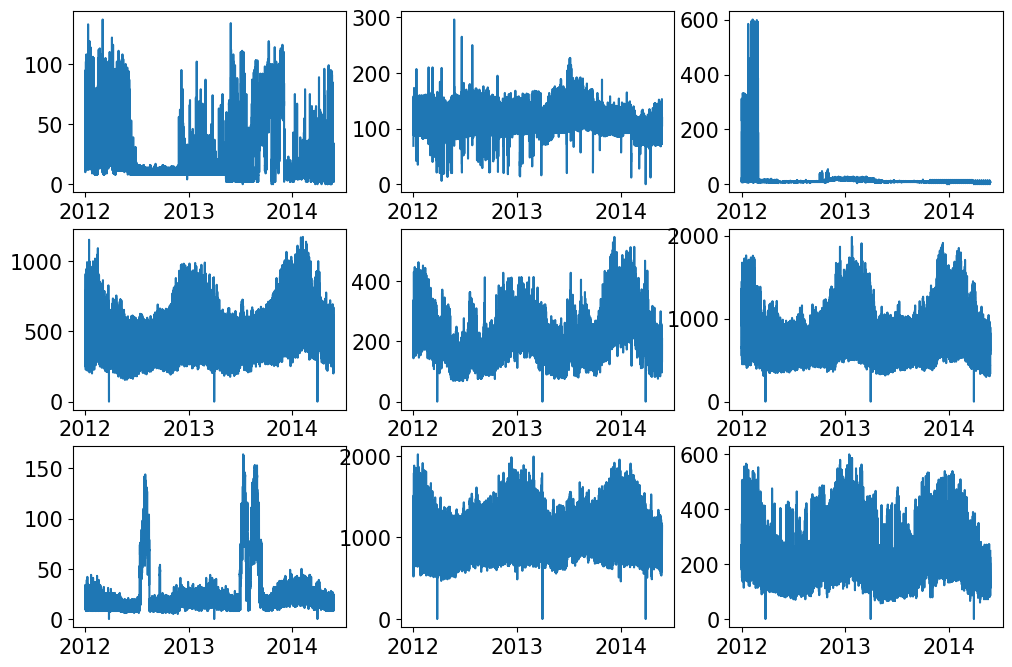

In [46]:
# format x-axis labels are years
date_formater = mdates.DateFormatter("%Y")

# create figure
fig = plt.figure(figsize=(12, 8))

# extract the first 9 time series from training set
for idx, entry in enumerate(islice(dataset.train, 9)):
    print(f'{idx}: {entry.keys()}')
        
    """
    entry is a dictionary containing four fields:
    - target: the actual values of the time series
    - start: the start date and time of the time series
    - feat_static_cat: idk what this is
    - item_id: same thing as index
    """
    
    # create subplot
    ax = plt.subplot(3, 3, idx + 1)
    
    # create time indices for each time series
    t = pd.date_range(
        start=entry["start"].to_timestamp(),  # start date
        periods=len(entry["target"]),  # number of time steps
        freq=entry["start"].freq,  # get frequency from pandas.Period object
    )
    plt.plot(t, entry["target"])  # plot time indices and time series values
    
    # formatting stuff
    plt.xticks(pd.date_range(start=entry["start"].to_timestamp(), periods=3, freq="YS"))
    ax.xaxis.set_major_formatter(date_formater)

## <a id='toc1_1_'></a>[Probabilistic feed-forward network using PyTorch](#toc0_)

We will use a pretty simple model, based on a feed-forward network whose output layer produces the parameters of a parametric distribution. By default, the model will use a Student's t-distribution, but this can be easily customized via the `distr_output` constructor argument.

Import packages

In [4]:
import torch
import torch.nn as nn

from gluonts.torch.model.predictor import PyTorchPredictor
from gluonts.torch.distributions import StudentTOutput
from gluonts.model.forecast_generator import DistributionForecastGenerator

In [5]:
def mean_abs_scaling(context, min_scale=1e-5):
    return context.abs().mean(1).clamp(min_scale, None).unsqueeze(1)

Define feed-forward network

In [6]:
class FeedForwardNetwork(nn.Module):
    def __init__(
        self,
        prediction_length: int,   
        context_length: int,  
        hidden_dimensions: List[int],  
        distr_output=StudentTOutput(),  
        batch_norm: bool = False,
        scaling: Callable = mean_abs_scaling,
    ) -> None:
        super().__init__()

        # number of future time steps to predict
        self.prediction_length = prediction_length
        
        # nunmber of past time steps to use when making predictions
        self.context_length = context_length
        
        # number of dimensions in each hidden layer
        self.hidden_dimensions = hidden_dimensions
        
        # make model output the parameters for a student t distribution
        # https://ts.gluon.ai/stable/api/gluonts/gluonts.torch.distributions.studentT.html#gluonts.torch.distributions.studentT.StudentT
        self.distr_output = distr_output
        
        # Whether or not to apply batch normalization
        self.batch_norm = batch_norm
        
        #  A function to scale the input time series (default: mean_abs_scaling)
        self.scaling = scaling

        # Dynamically creates a multi-layer feedforward network.
        dimensions = [context_length] + hidden_dimensions[:-1]
        modules = []
        for in_size, out_size in zip(dimensions[:-1], dimensions[1:]):
            modules += [self.__make_lin(in_size, out_size), nn.ReLU()]
            if batch_norm:
                modules.append(nn.BatchNorm1d(out_size))
        modules.append(
            self.__make_lin(dimensions[-1], prediction_length * hidden_dimensions[-1])
        )
        
        # Stores the network as a Sequential model.
        self.nn = nn.Sequential(*modules)
        
        # This projects the network’s output into parameters of the probability distribution (e.g., mean, variance for StudentTOutput).
        # https://ts.gluon.ai/stable/api/gluonts/gluonts.torch.distributions.html?highlight=get_args_proj#gluonts.torch.distributions.Output.get_args_proj
        self.args_proj = self.distr_output.get_args_proj(hidden_dimensions[-1])

    # makes linear layer
    @staticmethod
    def __make_lin(dim_in, dim_out):
        lin = nn.Linear(dim_in, dim_out)
        torch.nn.init.uniform_(lin.weight, -0.07, 0.07)
        torch.nn.init.zeros_(lin.bias)
        return lin

    def forward(self, past_target):
        # scale past time series values
        scale = self.scaling(past_target)
        
        # scale future time series values
        scaled_past_target = past_target / scale
        
        # forward pass
        nn_out = self.nn(scaled_past_target)
        
        # reshape predicted values into (batch_size, prediction_length, last_hidden_dim)
        nn_out_reshaped = nn_out.reshape(
            -1, self.prediction_length, self.hidden_dimensions[-1]
        )
        
        # TODO: change TEMPO so it outputs student's t distribution parameters
        
        # convert forward pass's outputs into parameters of a student's t distribution
        # https://ts.gluon.ai/stable/api/gluonts/gluonts.torch.distributions.html?highlight=get_args_proj#gluonts.torch.distributions.Output.get_args_proj
        distr_args = self.args_proj(nn_out_reshaped)
        return (distr_args,  # student's t distribtion parameters
                torch.zeros_like(scale),  # placeholder
                scale,)  # original scaling factor to use for denormalization

    def get_predictor(self, input_transform, batch_size=32):
        """
        returns predictor for performing inference
        """
        return PyTorchPredictor(
            prediction_length=self.prediction_length,  
            input_names=["past_target"],  # key in batch where past time series values are 
            prediction_net=self,  # model that'll be doing the predicting
            batch_size=batch_size, 
            input_transform=input_transform,  # applies some sort of transformation to the model's inputs
            forecast_generator=DistributionForecastGenerator(self.distr_output),  # converts the outputs of a probabilistic model into actual forecasts
        )

To train the model using PyTorch Lightning, we only need to extend the class with methods that specify how training steps are supposed to work. Please refer to [documentation for PyTorch Lightning](https://pytorch-lightning.readthedocs.io/en/stable/) to know more about the interface you need to implement in order to fully customize the training procedure.

In [7]:
import lightning.pytorch as pl

In [31]:
"""
define lightning module to wrap around model
"""
class LightningFeedForwardNetwork(FeedForwardNetwork, pl.LightningModule):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def training_step(self, batch, batch_idx):
        """
        batch is a dictionary containing a "past_target" key and a "future_target" key
        acccess these keys to get the past and future values of the time series
        """
        print(batch.keys())
        past_target = batch["past_target"]
        future_target = batch["future_target"]

        # perform forward pass
        (distr_args, # parameters for students t distribution
         loc,  # location (aka mean) - not used in student t distribtion
         scale,) = self(past_target)  
        
        # construct student t distribution
        # returns torch.distributions.distribution.Distribution
        # https://ts.gluon.ai/stable/api/gluonts/gluonts.torch.distributions.html?highlight=gluonts%20torch%20distributions#gluonts.torch.distributions.DistributionOutput.distribution
        distr = self.distr_output.distribution(distr_args, loc, scale)  
        
        # compute student t NLL 
        # https://pytorch.org/docs/stable/distributions.html#torch.distributions.distribution.Distribution.log_prob
        loss = -distr.log_prob(future_target)

        return loss.mean()

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

We can now instantiate the training network, and explore its set of parameters.

In [9]:
context_length = 2 * 7 * 24
prediction_length = dataset.metadata.prediction_length
hidden_dimensions = [96, 48]

In [10]:
net = LightningFeedForwardNetwork(
    prediction_length=prediction_length,
    context_length=context_length,
    hidden_dimensions=hidden_dimensions,
    distr_output=StudentTOutput(),
)

In [11]:
sum(np.prod(p.shape) for p in net.parameters())

np.int64(144243)

In [12]:
for p in net.parameters():
    print(p.shape)

torch.Size([96, 336])
torch.Size([96])
torch.Size([1152, 96])
torch.Size([1152])
torch.Size([1, 48])
torch.Size([1])
torch.Size([1, 48])
torch.Size([1])
torch.Size([1, 48])
torch.Size([1])


## <a id='toc1_2_'></a>[Defining the training data loader](#toc0_)

We now set up the data loader which will yield batches of data to train on. Starting from the original dataset, the data loader is configured to apply the following transformation, which does essentially two things:
* Replaces `nan`s in the target field with a dummy value (zero), and adds a field indicating which values were actually observed vs imputed this way.
* Slices out training instances of a fixed length randomly from the given dataset; these will be stacked into batches by the data loader itself.

In [13]:
from gluonts.dataset.field_names import FieldName
from gluonts.transform import (
    AddObservedValuesIndicator,
    InstanceSplitter,  # https://ts.gluon.ai/stable/api/gluonts/gluonts.transform.html?highlight=instancesplitter#gluonts.transform.InstanceSplitter
    ExpectedNumInstanceSampler,  # https://ts.gluon.ai/stable/api/gluonts/gluonts.transform.html?highlight=expectednuminstancesampler#gluonts.transform.ExpectedNumInstanceSampler
    TestSplitSampler,  # https://ts.gluon.ai/stable/api/gluonts/gluonts.transform.sampler.html?highlight=testsplitsampler#gluonts.transform.sampler.TestSplitSampler
)

In [14]:
# impute nan values
mask_unobserved = AddObservedValuesIndicator(
    target_field=FieldName.TARGET,
    output_field=FieldName.OBSERVED_VALUES,
)

In [15]:
# split instances in training set
training_splitter = InstanceSplitter(
    target_field=FieldName.TARGET,  # field containing the target
    is_pad_field=FieldName.IS_PAD,  # output field indicating whether padding happened
    start_field=FieldName.START,  # field containing the start date of the time series
    forecast_start_field=FieldName.FORECAST_START,  # output field that will contain the time point where the forecast starts
    instance_sampler=ExpectedNumInstanceSampler(
        num_instances=1,
        min_future=prediction_length,
    ),  # instance sampler that provides sampling indices given a time series
    past_length=context_length,  # length of the target seen before making prediction
    future_length=prediction_length,  # length of the target that must be predicted
    time_series_fields=[FieldName.OBSERVED_VALUES],  # fields that contains time series, they are split in the same interval as the target 
)

In [16]:
from gluonts.dataset.loader import TrainDataLoader
from gluonts.itertools import Cached
from gluonts.torch.batchify import batchify

In [17]:
batch_size = 32
num_batches_per_epoch = 50

In [18]:
data_loader = TrainDataLoader(
    # We cache the dataset, to make training faster
    Cached(dataset.train),
    batch_size=batch_size,
    stack_fn=batchify,
    transform=mask_unobserved + training_splitter,
    num_batches_per_epoch=num_batches_per_epoch,
)

## <a id='toc1_3_'></a>[Train the model](#toc0_)

We can now train the model using the tooling that PyTorch Lightning provides:

In [19]:
trainer = pl.Trainer(max_epochs=10)
trainer.fit(net, data_loader)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
INFO: 
  | Name      | Type       | Params | Mode 
-------------------------------------------------
0 | nn        | Sequential | 144 K  | train
1 | args_proj | PtArgProj  | 147    | train
-------------------------------------------------
144 K     Trainable params
0         Non-trainable params
144 K     Total params
0.577     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode
INFO:lightning.pytorch.callbacks.

Epoch 9: |          | 50/? [00:00<00:00, 53.63it/s, v_num=14]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


Epoch 9: |          | 50/? [00:00<00:00, 52.80it/s, v_num=14]


## <a id='toc1_4_'></a>[Create predictor out of the trained model, and test it](#toc0_)

Now we can get the predictor out of our model, and use it to make forecasts.

In [20]:
prediction_splitter = InstanceSplitter(
    target_field=FieldName.TARGET,
    is_pad_field=FieldName.IS_PAD,
    start_field=FieldName.START,
    forecast_start_field=FieldName.FORECAST_START,
    instance_sampler=TestSplitSampler(),
    past_length=context_length,
    future_length=prediction_length,
    time_series_fields=[FieldName.OBSERVED_VALUES],
)

In [21]:
predictor_pytorch = net.get_predictor(mask_unobserved + prediction_splitter)

For example, we can do backtesting on the test dataset: in what follows, `make_evaluation_predictions` will slice out the trailing `prediction_length` observations from the test time series, and use the given predictor to obtain forecasts for the same time range.

In [22]:
from gluonts.evaluation import make_evaluation_predictions, Evaluator

In [23]:
forecast_it, ts_it = make_evaluation_predictions(
    dataset=dataset.test, predictor=predictor_pytorch
)

forecasts_pytorch = list(f.to_sample_forecast() for f in forecast_it)
tss_pytorch = list(ts_it)

Once we have the forecasts, we can plot them:

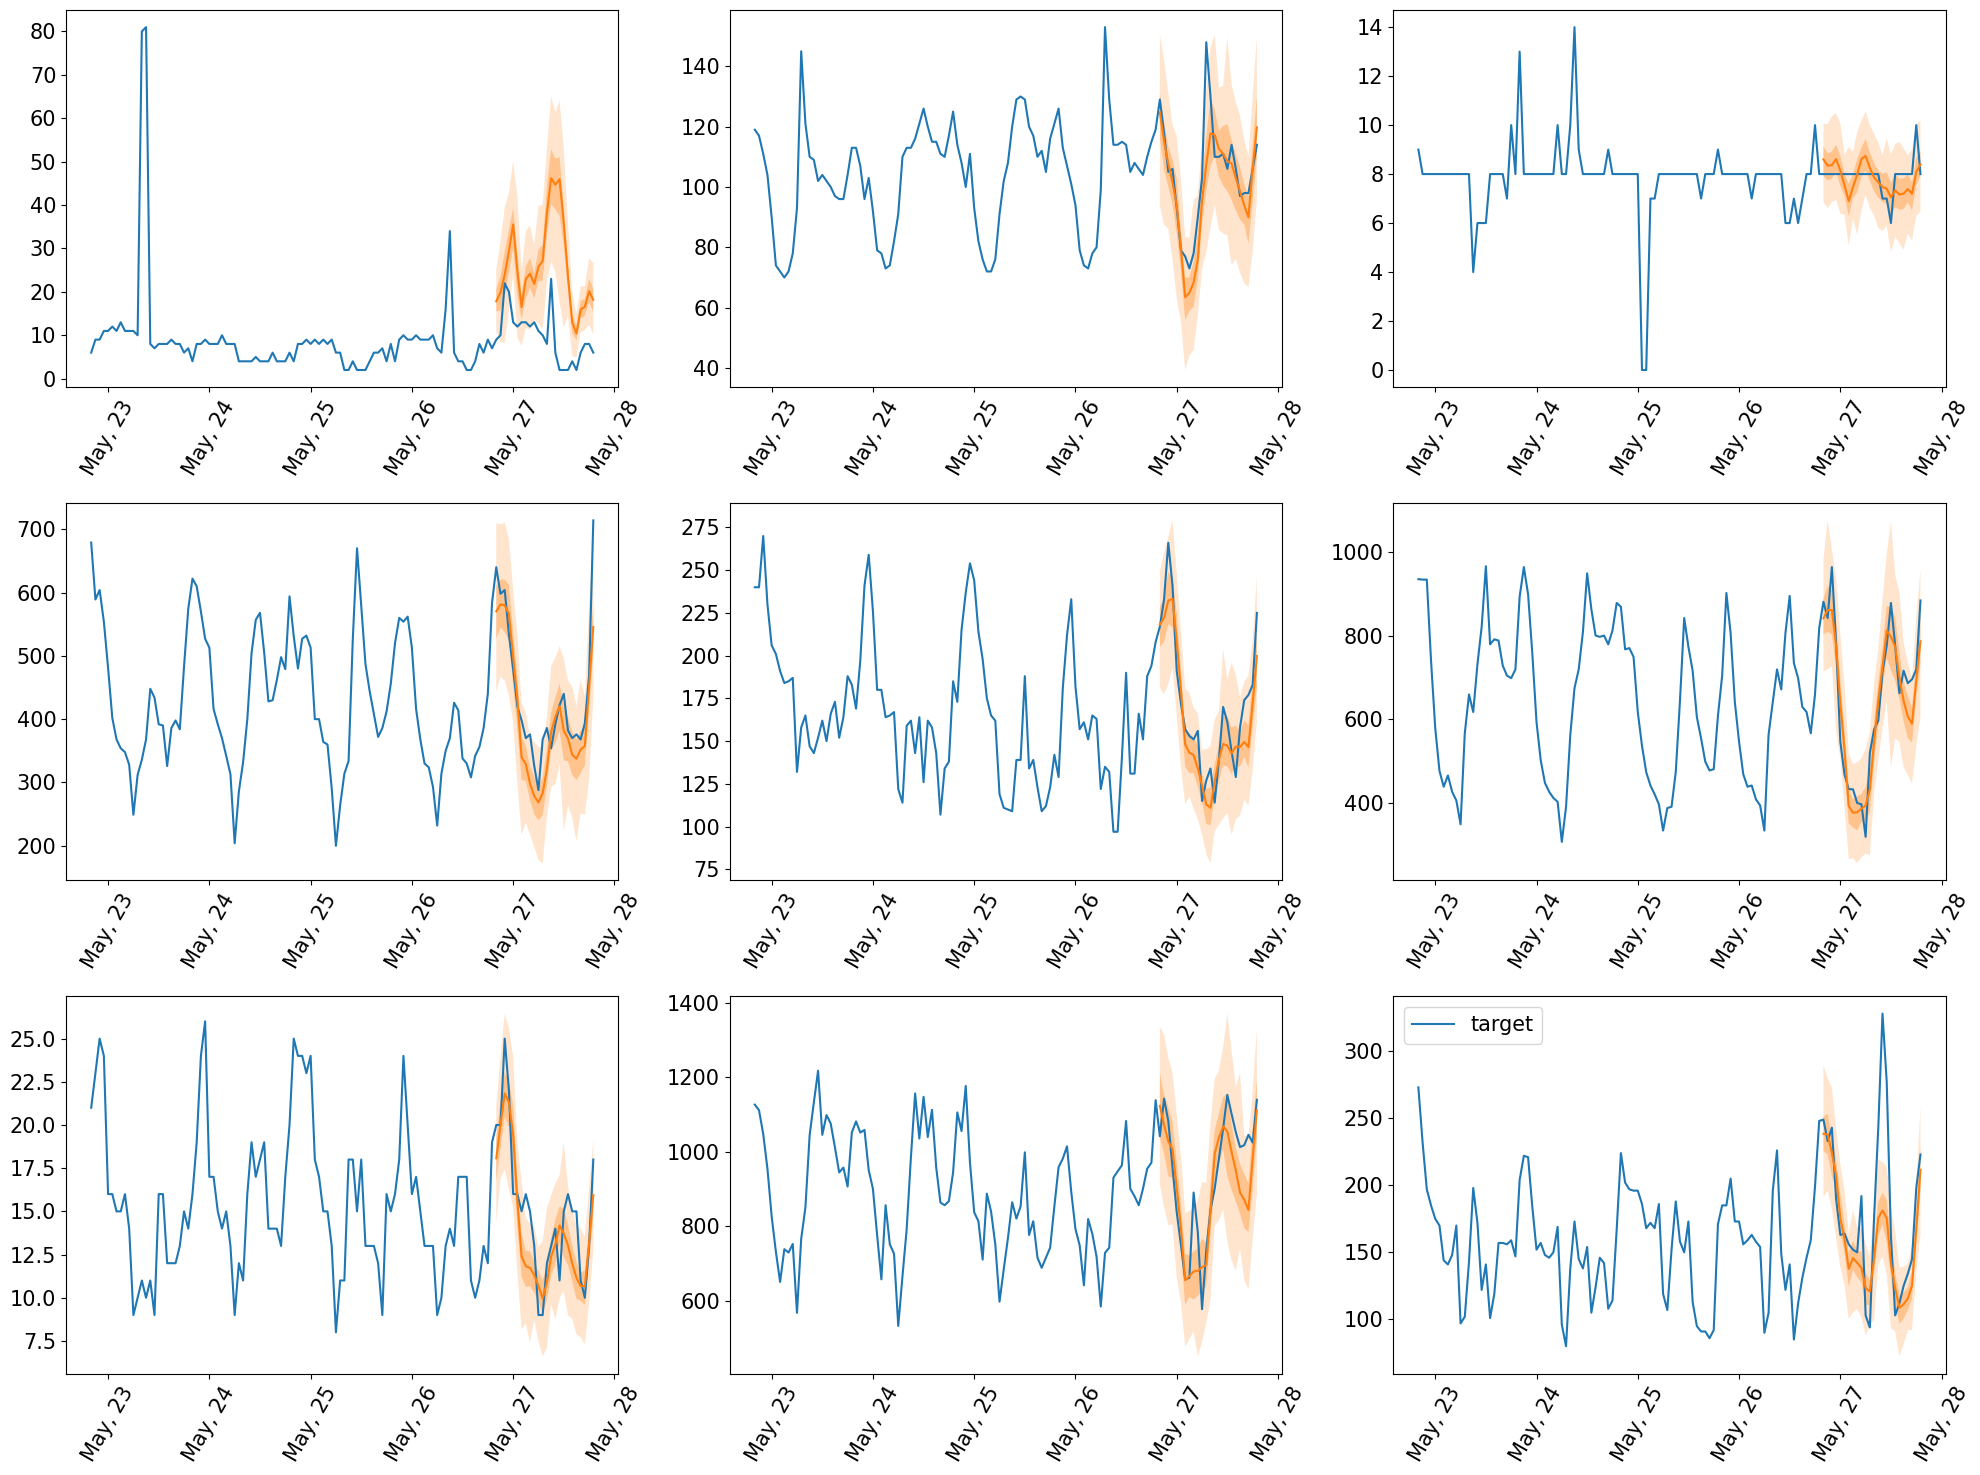

In [24]:
plt.figure(figsize=(20, 15))
date_formater = mdates.DateFormatter("%b, %d")
plt.rcParams.update({"font.size": 15})

for idx, (forecast, ts) in islice(enumerate(zip(forecasts_pytorch, tss_pytorch)), 9):
    ax = plt.subplot(3, 3, idx + 1)
    plt.plot(ts[-5 * prediction_length :].to_timestamp(), label="target")
    forecast.plot()
    plt.xticks(rotation=60)
    ax.xaxis.set_major_formatter(date_formater)

plt.gcf().tight_layout()
plt.legend()
plt.show()

And we can compute evaluation metrics, that summarize the performance of the model on our test data.

In [25]:
evaluator = Evaluator(quantiles=[0.1, 0.5, 0.9])

In [26]:
metrics_pytorch, _ = evaluator(tss_pytorch, forecasts_pytorch)
pd.DataFrame.from_records(metrics_pytorch, index=["FeedForward"]).transpose()

Running evaluation: 2247it [00:09, 233.86it/s]
c:\Users\Mike\anaconda3\envs\gts\Lib\site-packages\pandas\core\dtypes\astype.py:133: UserWarning: Warning: converting a masked element to nan.
  return arr.astype(dtype, copy=True)


,FeedForward
Coverage[0.1],6.404836e-02
Coverage[0.5],3.979936e-01
Coverage[0.9],8.870346e-01
MAE_Coverage,3.956782e-01
MAPE,1.622805e-01
MASE,1.132007e+00
MSE,4.448938e+06
MSIS,9.463062e+00
ND,1.055592e-01
NRMSE,8.842809e-01
